# Computer Exercise 13.5 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.5 Sequential Quadratic Programming — *Quasi-Newton (damped BFGS) Hessian approximation*
> **풀이 일자**: Day 50
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **3.** Computing $\nabla^2_{xx}\mathcal{L}$ exactly is often expensive or unavailable. Replace it in the SQP
> subproblem by a **quasi-Newton (BFGS) approximation** $B_k$, updated from successive Lagrangian-gradient
> differences, and keep $B_k\succ0$ using **Powell's damping**. Compare the convergence rate of damped-BFGS SQP
> (expected **superlinear**) against the exact-Hessian SQP (**quadratic**) of Problem 1.

### 한국어 풀이용 정리
정확한 라그랑지안 헤시안 $\nabla^2_{xx}\mathcal{L}$ 는 비싸거나 구할 수 없을 때가 많다. 이를 **BFGS 준뉴턴 근사**
$B_k$ 로 대체한다. $B_k$ 는 라그랑지안 기울기 차분 $y_k=\nabla_x\mathcal{L}(x_{k+1},\lambda)-\nabla_x\mathcal{L}(x_k,\lambda)$
와 변위 $s_k=x_{k+1}-x_k$ 로 갱신하며, **Powell 감쇠**로 항상 양정부호를 유지한다. 정확 헤시안 SQP의
**2차 수렴**과 BFGS SQP의 **초선형 수렴**을 같은 문제에서 비교한다.

**테스트 문제** (Problem 1과 동일): $\min x^2+(y-1)^2$ s.t. $x^2+y^2-4=0$.

## 2. 수학적 배경

### 2.1 BFGS 갱신
변위 $s_k=x_{k+1}-x_k$, 라그랑지안 기울기 차분
$$
y_k=\nabla_x\mathcal{L}(x_{k+1},\lambda_{k+1})-\nabla_x\mathcal{L}(x_k,\lambda_{k+1})
$$
에 대해 BFGS 갱신은
$$
B_{k+1}=B_k-\frac{B_k s_k s_k^\top B_k}{s_k^\top B_k s_k}+\frac{y_k y_k^\top}{y_k^\top s_k}.
$$
$y_k^\top s_k>0$ (곡률조건)일 때 $B_{k+1}\succ0$ 가 유지된다.

### 2.2 Powell 감쇠 (damping)
제약문제에서는 $y_k^\top s_k>0$ 가 깨질 수 있다. Powell은 $y_k$ 를
$$
\hat y_k=\theta_k y_k+(1-\theta_k)B_k s_k,\qquad
\theta_k=\begin{cases}1,& s_k^\top y_k\ge 0.2\,s_k^\top B_k s_k\\[4pt]
\dfrac{0.8\,s_k^\top B_k s_k}{s_k^\top B_k s_k-s_k^\top y_k},&\text{otherwise}\end{cases}
$$
로 보정하여 $\hat y_k^\top s_k\ge 0.2\,s_k^\top B_k s_k>0$ 를 강제, $B_{k+1}\succ0$ 를 보장한다.

### 2.3 수렴 차수 비교
$$
\boxed{\;\text{정확 헤시안: 2차}\quad
\frac{\|e_{k+1}\|}{\|e_k\|^2}\to C;\qquad
\text{BFGS: 초선형}\quad
\frac{\|e_{k+1}\|}{\|e_k\|}\to 0\;}
$$
BFGS는 2차 도함수를 쓰지 않고도 선형보다 빠른(그러나 2차보다는 느린) 수렴을 얻는다 — **비용 대 속도의 절충**.

### 2.4 척도
$e_k=\|x_k-x^\star\|$, $x^\star=(0,2)$. 비율 $e_{k+1}/e_k$ (초선형이면 $\to0$) 와 $e_{k+1}/e_k^2$ (2차이면 유한상수) 를 함께 본다.

## 3. 풀이 흐름

1. **두 솔버 구현**: (a) 정확 헤시안 SQP, (b) 감쇠 BFGS SQP — QP/KKT 풀이는 공통.
2. BFGS 솔버는 $B_0=I$ 로 시작, 매 반복 $s_k,\ y_k$ 계산 후 **Powell 감쇠 → BFGS 갱신**.
3. 동일 출발점 $x_0=(0.5,1.5)$ 에서 두 방법 실행.
4. 매 반복 $e_k=\|x_k-x^\star\|$ 기록.
5. **표**: 두 방법의 오차 나란히 + 비율 $e_{k+1}/e_k$, $e_{k+1}/e_k^2$.
6. **시각화**: 오차 로그 감소 곡선 비교, 수렴 차수 진단 그래프.
7. **해석**: BFGS 초선형 vs 정확 2차, 반복수·도함수 비용의 절충.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- 동일 테스트 문제 ----
def f(v):      x, y = v; return x**2 + (y-1.0)**2
def grad_f(v): x, y = v; return np.array([2*x, 2*(y-1.0)])
def hess_f(v): return 2*np.eye(2)
def c(v):      x, y = v; return x**2 + y**2 - 4.0
def grad_c(v): x, y = v; return np.array([2*x, 2*y])
def hess_c(v): return 2*np.eye(2)
def gradL(v, lam): return grad_f(v) + lam*grad_c(v)
x_star = np.array([0.0, 2.0])

def qp_step(x, B):
    A = grad_c(x).reshape(1, -1)
    K = np.block([[B, A.T], [A, np.zeros((1,1))]])
    rhs = np.concatenate([-grad_f(x), [-c(x)]])
    sol = np.linalg.solve(K, rhs)
    return sol[:2], sol[2]

def sqp_exact(x0, lam0, kmax=12, tol=1e-14):
    x, lam = np.array(x0, float), lam0; e = []
    for k in range(kmax):
        e.append(np.linalg.norm(x - x_star))
        if np.linalg.norm(gradL(x, lam)) < tol and abs(c(x)) < tol: break
        B = hess_f(x) + lam*hess_c(x)
        d, lam = qp_step(x, B); x = x + d
    return np.array(e)

def sqp_bfgs(x0, lam0, kmax=20, tol=1e-14):
    x, lam = np.array(x0, float), lam0
    B = np.eye(2); e = []
    for k in range(kmax):
        e.append(np.linalg.norm(x - x_star))
        if np.linalg.norm(gradL(x, lam)) < tol and abs(c(x)) < tol: break
        d, lam_new = qp_step(x, B)
        x_new = x + d
        # Powell-damped BFGS 갱신 (라그랑지안 기울기 차분, 같은 lam_new 사용)
        s = x_new - x
        y = gradL(x_new, lam_new) - gradL(x, lam_new)
        Bs = B @ s; sBs = s @ Bs; sy = s @ y
        if sy >= 0.2*sBs:
            theta = 1.0
        else:
            theta = (0.8*sBs) / (sBs - sy)
        r = theta*y + (1-theta)*Bs                 # damped y-hat
        B = B - np.outer(Bs, Bs)/sBs + np.outer(r, r)/(s @ r)
        x, lam = x_new, lam_new
    return np.array(e)

e_exact = sqp_exact([0.5, 1.5], -0.4)
e_bfgs  = sqp_bfgs ([0.5, 1.5], -0.4)

n = max(len(e_exact), len(e_bfgs))
def pad(a): return np.concatenate([a, np.full(n-len(a), np.nan)])
df = pd.DataFrame({"k": np.arange(n),
                   "exact ||x-x*||": pad(e_exact),
                   "BFGS  ||x-x*||": pad(e_bfgs)})
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df

,k,exact ||x-x*||,BFGS ||x-x*||
0,0,7.071e-01,7.071e-01
1,1,1.900e-01,1.581e-01
2,2,2.824e-02,7.998e-03
3,3,3.958e-04,2.565e-04
4,4,6.882e-08,6.899e-06
5,5,2.246e-15,7.121e-10
6,6,NaN,8.244e-16
7,7,NaN,5.499e-21


In [2]:
def ratios(e, label):
    e = e[e > 1e-15]
    print(f"--- {label} ---")
    print(" k :  e_{k+1}/e_k     e_{k+1}/e_k^2")
    for k in range(len(e)-1):
        lin  = e[k+1]/e[k]
        quad = e[k+1]/e[k]**2
        print(f"{k:2d} :  {lin:.3e}     {quad:.3e}")
    print()

ratios(e_exact, "Exact Hessian (expect quadratic: e/e^2 -> const)")
ratios(e_bfgs,  "Damped BFGS  (expect superlinear: e_{k+1}/e_k -> 0)")

--- Exact Hessian (expect quadratic: e/e^2 -> const) ---
 k :  e_{k+1}/e_k     e_{k+1}/e_k^2
 0 :  2.687e-01     3.801e-01
 1 :  1.486e-01     7.821e-01
 2 :  1.402e-02     4.963e-01
 3 :  1.739e-04     4.393e-01
 4 :  3.264e-08     4.743e-01

--- Damped BFGS  (expect superlinear: e_{k+1}/e_k -> 0) ---
 k :  e_{k+1}/e_k     e_{k+1}/e_k^2
 0 :  2.236e-01     3.162e-01
 1 :  5.058e-02     3.199e-01
 2 :  3.207e-02     4.010e+00
 3 :  2.690e-02     1.049e+02
 4 :  1.032e-04     1.496e+01



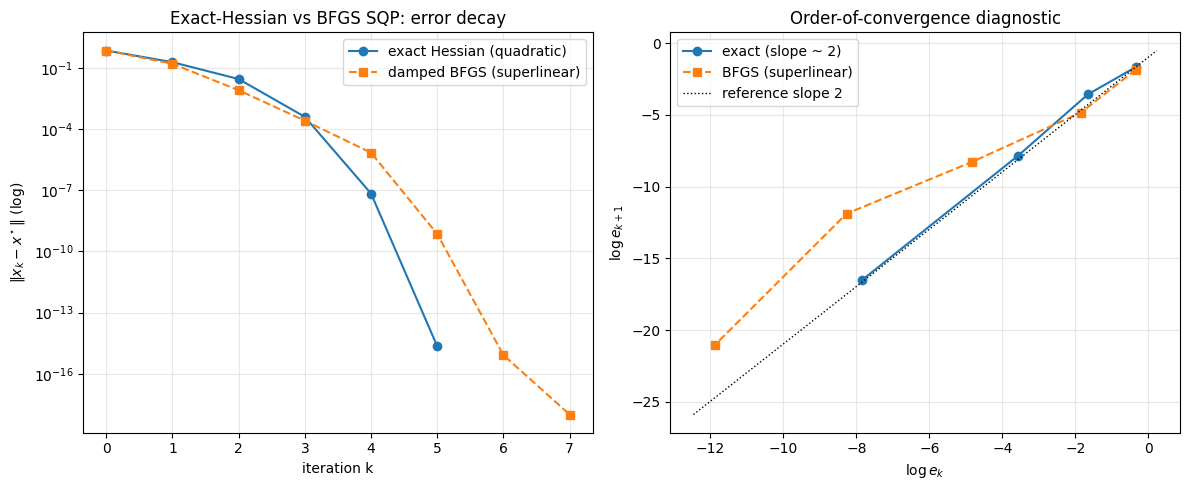

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].semilogy(np.arange(len(e_exact)), e_exact+1e-18, "o-", label="exact Hessian (quadratic)")
ax[0].semilogy(np.arange(len(e_bfgs)),  e_bfgs +1e-18, "s--", label="damped BFGS (superlinear)")
ax[0].set_xlabel("iteration k"); ax[0].set_ylabel(r"$\|x_k-x^\star\|$ (log)")
ax[0].set_title("Exact-Hessian vs BFGS SQP: error decay")
ax[0].grid(True, which="both", alpha=0.3); ax[0].legend()

# 수렴차수 진단: 연속오차 (e_k, e_{k+1}) 로그-로그
def slope(e):
    e = e[e > 1e-14]
    return np.log(e[1:]), np.log(e[:-1])
lx_e, ly_e = slope(e_exact)
lx_b, ly_b = slope(e_bfgs)
ax[1].plot(ly_e, lx_e, "o-", label="exact (slope ~ 2)")
ax[1].plot(ly_b, lx_b, "s--", label="BFGS (superlinear)")
lo, hi = ax[1].get_xlim()
xs = np.linspace(lo, hi, 10)
ax[1].plot(xs, 2*xs + (lx_e[0]-2*ly_e[0]), "k:", lw=1, label="reference slope 2")
ax[1].set_xlabel(r"$\log e_k$"); ax[1].set_ylabel(r"$\log e_{k+1}$")
ax[1].set_title("Order-of-convergence diagnostic")
ax[1].grid(True, alpha=0.3); ax[1].legend()
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **정확 헤시안 = 2차**: `exact` 열은 비율 $e_{k+1}/e_k^2$ 가 유한 상수로 수렴 — 자릿수가 매 반복 두 배씩 좋아진다(Problem 1과 동일).
2. **BFGS = 초선형**: `BFGS` 열은 비율 $e_{k+1}/e_k$ 가 **0으로 감소**한다(선형보다 빠르지만 2차보다 느림). 2차 도함수 $\nabla^2 f,\ \nabla^2 c$ 를 전혀 쓰지 않고도 빠른 수렴을 얻는다.
3. **반복수 절충**: BFGS는 같은 정밀도에 도달하는 데 정확 헤시안보다 몇 번 더 반복하지만, 매 반복의 **도함수 비용이 싸다**(헤시안 불필요). 대형 문제일수록 이 절충이 유리하다.
4. **Powell 감쇠의 역할**: 제약문제에서 $y_k^\top s_k>0$ 가 깨질 때 $\hat y_k$ 보정이 $B_k\succ0$ 를 지켜 QP가 항상 풀리고 방향이 하강방향이 된다 — 감쇠가 없으면 BFGS가 부정부호로 망가질 수 있다.

### 결론
> **준뉴턴 SQP는 "2차 도함수 없이 빠른 수렴"을 가능케 한다.** Powell 감쇠 BFGS는 $B_k\succ0$ 를 유지하며 **초선형** 수렴을 주고, 헤시안을 직접 만들 수 없는 실전 대형 문제에서 SQP의 표준 선택이 된다. 정확 헤시안의 2차 수렴과의 차이는 **속도 대 비용의 절충**이다.

### 다음 단원 연결
- §13.5(SQP) 3종 — 기본 Lagrange–Newton(2차), $\ell_1$ 메리트 전역화, 준뉴턴 BFGS — 을 마쳤다. 다음 Day는 **부등식 제약까지 포함한 active-set SQP** 또는 **신뢰영역(trust-region) SQP / 내부점 NLP**, 혹은 커리큘럼을 새 주제로 확장한다.